In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
train.isnull().sum()[train.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [6]:
highly_missing_features = ["LotFrontage","Alley",
                           "MasVnrType","FireplaceQu",
                           "PoolQC","Fence","MiscFeature"]

In [7]:
num_col = train.select_dtypes(include="number").columns

In [8]:
num_col

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [9]:
corr_matrix = train[num_col].corr()

## Top 10 highly related features to SalePrice(target variable) except TV itself

In [10]:
highly_related_2sales = corr_matrix["SalePrice"].sort_values(ascending=False)[1:11]

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

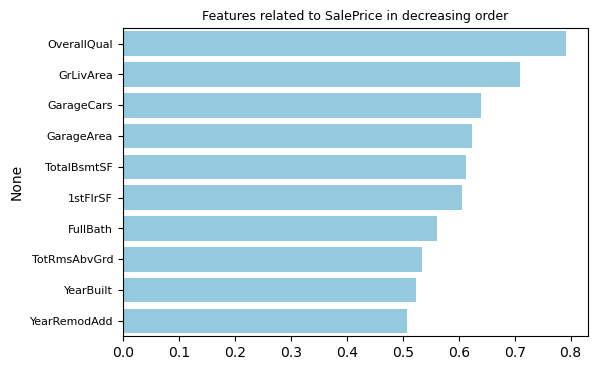

In [12]:
plt.figure(figsize=(6,4))
plt.title("Features related to SalePrice in decreasing order",size=9)
sns.barplot(x=highly_related_2sales.values, y=highly_related_2sales.index,color="skyblue")
plt.yticks(size=8)
plt.show()

In [13]:
unwanted_feature = []
for feature in highly_missing_features:
    if feature not in highly_related_2sales:
        unwanted_feature.append(feature)

In [14]:
unwanted_feature

['LotFrontage',
 'Alley',
 'MasVnrType',
 'FireplaceQu',
 'PoolQC',
 'Fence',
 'MiscFeature']

These features have very less relation with target veriable and have a lot of missing values

In [15]:
train.drop(columns=unwanted_feature, inplace = True)

In [16]:
test.drop(columns=unwanted_feature, inplace = True)

In [17]:
train.columns 

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch'

# Basement columns

    BsmtExposure: Walkout or garden level basement walls
    BsmtQual: Quality 
    BsmtCond: condition 
    Have to apply label encoding

**TotalBsmtSF**: 
    BsmtFinSF1: Finished square feet of basement (type 1)
    BsmtFinSF2: Finished square feet of basement (type 2)
    BsmtUnfSF: Unfinished basement square feet

Total basement square feet (this is the sum of BsmtFinSF1, BsmtFinSF2 and BsmtUnfSF)
*we can simply drop these three (BsmtFinSF1, BsmtFinSF2 and BsmtUnfSF)*



In [18]:
basement_columns = ['BsmtQual', 'BsmtCond', 'BsmtExposure',
 'BsmtFinType1','BsmtFinSF1', 'BsmtFinType2',
 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']

In [19]:
train[basement_columns]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
0,Gd,TA,No,GLQ,706,Unf,0,150,856
1,Gd,TA,Gd,ALQ,978,Unf,0,284,1262
2,Gd,TA,Mn,GLQ,486,Unf,0,434,920
3,TA,Gd,No,ALQ,216,Unf,0,540,756
4,Gd,TA,Av,GLQ,655,Unf,0,490,1145
...,...,...,...,...,...,...,...,...,...
1455,Gd,TA,No,Unf,0,Unf,0,953,953
1456,Gd,TA,No,ALQ,790,Rec,163,589,1542
1457,TA,Gd,No,GLQ,275,Unf,0,877,1152
1458,TA,TA,Mn,GLQ,49,Rec,1029,0,1078


In [20]:
basement_num_columns = ["BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","TotalBsmtSF"]
basement_cat_columns = [col for col in basement_columns if col not in basement_num_columns]

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

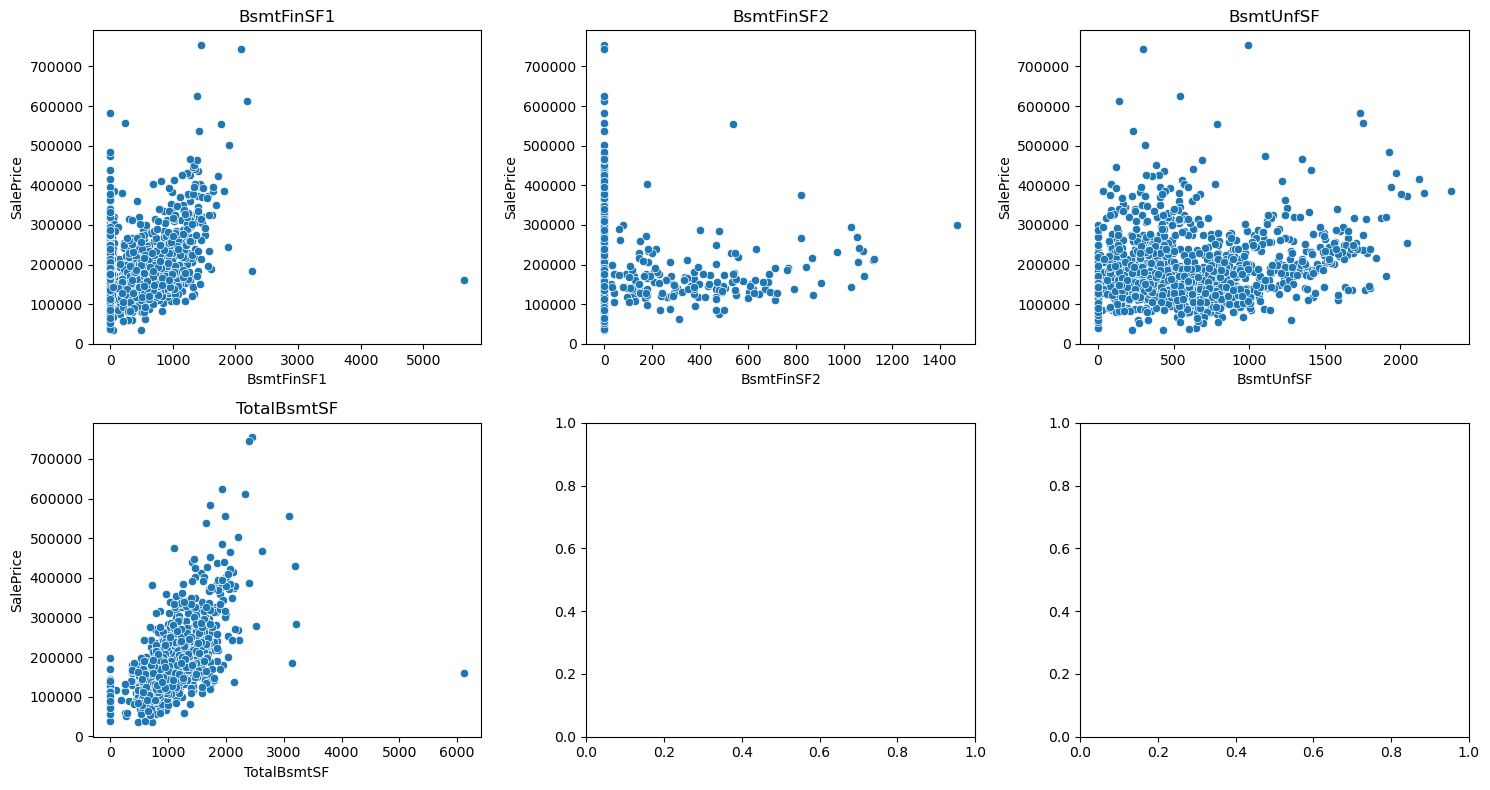

In [22]:
n_cols = 3
n_rows = math.ceil(len(basement_num_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(basement_num_columns):
    sns.scatterplot(
        x=train[col],
        y=train["SalePrice"],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

SalePrice mostly depending on TotalBsmtSF, Slightly less on BsmtFinSF1 and very less in SF2 and UnfSF
we will remove those three columns also they are not in our most corr columns list

In [23]:
train.drop(["BsmtFinSF1","BsmtFinSF2","BsmtUnfSF"], inplace=True, axis=1)
test.drop(["BsmtFinSF1","BsmtFinSF2","BsmtUnfSF"], inplace=True, axis=1)

In [24]:
basement_cat_columns

['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

In [25]:
print(f"'BsmtFinType1' have {train['BsmtFinType1'].isnull().sum()}/{train['BsmtFinType1'].count()+train['BsmtFinType1'].isnull().sum()} null values")
print(f"'BsmtFinType2' have {train['BsmtFinType2'].isnull().sum()}/{(train['BsmtFinType2'].count()+train['BsmtFinType2'].isnull().sum())} null values")

'BsmtFinType1' have 37/1460 null values
'BsmtFinType2' have 38/1460 null values


[]

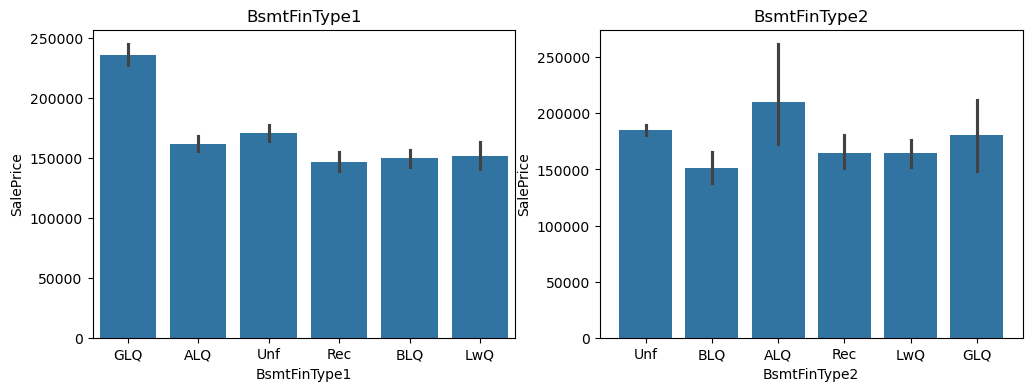

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(121)
sns.barplot(x=train['BsmtFinType1'], y=train['SalePrice'])
plt.title('BsmtFinType1')
plt.subplot(122)
sns.barplot(x=train['BsmtFinType2'], y=train['SalePrice'])
plt.title('BsmtFinType2')
plt.plot()

In [27]:
from sklearn.compose import ColumnTransformer

In [28]:
transformations = ["BsmtFinType1_trans",LableEncoder()]

NameError: name 'LableEncoder' is not defined

In [ ]:
'''tuf1 = ColumnTransformer()
tuf1'''
